In [12]:
import ibis
from dev import reload_module_recursive
from ibis import deferred as _

import datasets
import pvm

reload_module_recursive(datasets)
reload_module_recursive(pvm)

In [7]:
# Load the sample sales dataset
sales_data = datasets.sales.raw
sales_data.head()

year,country,currency,sku,customer,unit_price,fx_rate,volume,flat_fee,cost_fx_rate,unit_cost,raw_material,yield_rate,price_in_lc,cost_in_lc,revenue,cost
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020,"""Bouvet Island (Bouvetoya)""","""ARS""","""SKU0""","""Wagner Inc""",17.026745,1.297332,92.128079,0.0,1.345544,13.050954,111.983827,0.822691,13.124437,9.699389,1568.641324,1202.359321
2020,"""Bouvet Island (Bouvetoya)""","""ARS""","""SKU0""","""Blake and Sons""",21.421555,1.297332,61.834549,0.0,1.335358,15.108032,70.547128,0.8765,16.512013,11.313846,1324.592174,934.198367
2020,"""Bouvet Island (Bouvetoya)""","""ARS""","""SKU0""","""Garcia-James""",16.432652,1.297332,76.142445,0.0,1.277265,12.590979,86.684116,0.87839,12.666502,9.8577635,1251.22229,958.707924
2020,"""Bouvet Island (Bouvetoya)""","""ARS""","""SKU1""","""Cole LLC""",93.051244,1.297332,68.342591,0.0,1.231454,59.789777,85.185419,0.80228,71.725108,48.552166,6359.363117,4086.188299
2020,"""Bouvet Island (Bouvetoya)""","""ARS""","""SKU1""","""Blake and Sons""",101.874756,1.297332,107.915653,2.8691221,1.244599,69.215268,127.356804,0.847349,78.526387,55.612514,10996.749991,7469.410897


In [13]:
con = ibis.polars.connect({"sales": sales_data})
sales = con.table("sales")

In [14]:
from pvm.measures import Measure, QuantityMeasure, RateMeasure

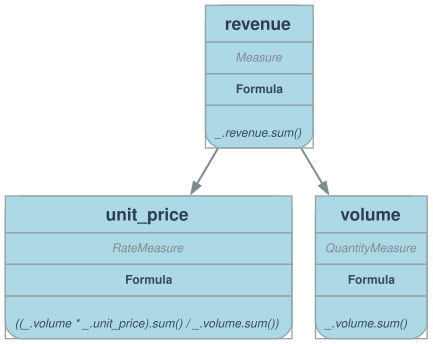

In [16]:
# Build a revenue graph with price and volume components
revenue_graph = Measure(
    "revenue",
    definition=_.revenue.sum(),
    components=[
        RateMeasure(
            "unit_price",
            definition=(_.volume * _.unit_price).sum() / _.volume.sum(),
        ),
        QuantityMeasure(
            "volume",
            definition=_.volume.sum(),
        ),
    ],
)

revenue_graph.display()

In [ ]:
# Set up PVM analysis: compare 2020 vs 2021 by country and SKU
from pvm.pvm import PVM

pvm_analysis = PVM().set_data(sales).set_periods(_.year, ["2020", "2021"]).set_hierarchy([]).set_graph(revenue_graph)

In [21]:
# Calculate price/volume effects
effects = pvm_analysis.calculate_effects().to_polars()
effects

revenue_2020,unit_price_2020,volume_2020,revenue_2021,unit_price_2021,volume_2021,revenue__change__2020,unit_price__change__2020,volume__change__2020
f64,f64,f64,f64,f64,f64,f64,f64,f64
421593.840955,60.740156,6942.092121,499253.134,57.531486,8677.32557,77659.293045,-3.20867,1735.233449
